In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import torch

In [3]:
def f(x):
    return 3*x**2 - 4*x + 5

In [4]:
x = 3.0
f(x)

20.0

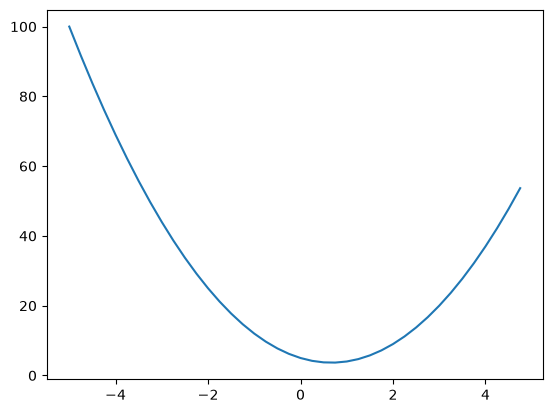

In [5]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [6]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [7]:
class Value:
   def __init__(self, data, _children=(), _op='', label=''):
       self.data = data
       self.grad = 0.0
       self.label = label
       self._prev = set(_children)
       self._op = _op
   def __repr__(self):
      return f"(Value = {self.data})"
   def __add__(self, other):
      other = other if isinstance(other,Value) else Value(other)
      return Value(self.data + other.data, (self, other), '+')
   def __mul__(self, other):
      other = other if isinstance(other,Value) else Value(other)
      return Value(self.data * other.data, (self, other), '*')

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b ; e.label='e'
d = e + c ; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
L

(Value = -8.0)

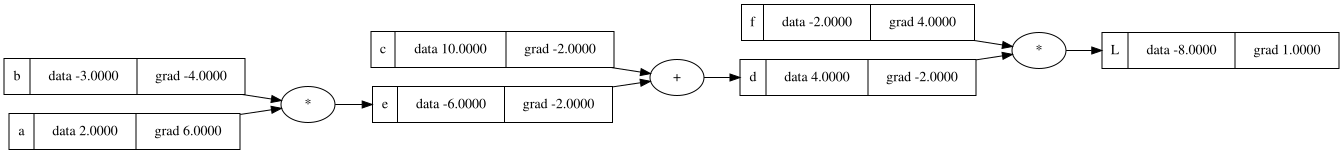

In [19]:
draw_dot(L)

In [9]:
## Manual backpropagation
L.grad = 1.0

""" L = d*f
dL/dd = f = -2.0
dL/df = d = 4.0 """

d.grad = -2.0 
f.grad = 4.0 

""" dL/dc = ?, dL/de = ?
L = d * f
d = e + c
L = e*f + c*f 
dL/dc = f = -2.0
dL/de = f = -2.0
"""

c.grad = -2.0
e.grad = -2.0

In [10]:
""" e = a*b
L = (a*b)*f + c*f

dL/da = ?, dL/db =?
dL/da = dL/de * de/da = -2.0 * b = -2.0 * - 3.0 = 6.0
dL/db = dL/de * de/db = -2.0 * a = -2.0 * 2.0 = -4.0 """

a.grad = 6.0
b.grad = -4.0

In [11]:
# same example with automatic backpropagation via .backward()

In [12]:
class Val:
   def __init__(self, data, _children=(), _op='', label=''):
       self.data = data
       self.grad = 0.0
       self._backward = lambda:None
       self.label = label
       self._prev = set(_children)
       self._op = _op
       
   def __repr__(self):
      return f"(Value = {self.data})"
       
   def __add__(self, other):
      other = other if isinstance(other,Val) else Val(other)
      out = Val(self.data + other.data, (self, other), '+')
      def _backward():
          self.grad += 1.0 * out.grad
          other.grad += 1.0 * out.grad
      out._backward = _backward
      return out
       
   def __mul__(self, other):
      other = other if isinstance(other,Val) else Val(other)
      out = Val(self.data * other.data, (self, other), '*')
      def _backward():
          self.grad += other.data * out.grad
          other.grad += self.data * out.grad
      out._backward = _backward
      return out
       
   def tanh(self):
       x = self.data
       t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
       out = Val(t, (self,), 'tanh')
       def _backward():
          self.grad += (1 - t**2) * out.grad
       out._backward = _backward
       return out
       
   def backward(self):
       topo = []
       visited = set()
       def build_topo(v):
           if v not in visited:
               visited.add(v)
               for child in v._prev: 
                  build_topo(child)
               topo.append(v)
       build_topo(self)

       self.grad = 1.0
       for node in reversed(topo):
           node._backward()

A = Val(2.0, label='a')
B = Val(-3.0, label='b')
C = Val(10.0, label='c')
E = A*B; E.label = 'e'
D = E + C; D.label = 'd'
F = Val(-2.0, label='f')
R = D * F; R.label = 'L'
R         

(Value = -8.0)

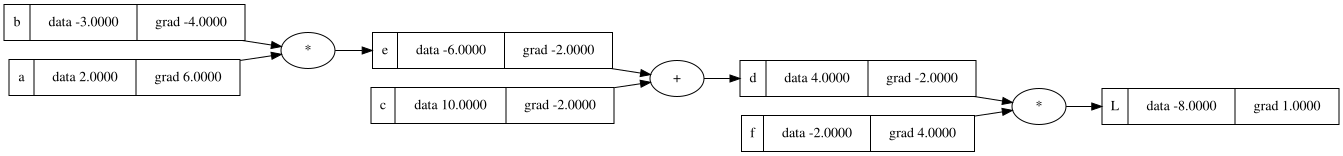

In [20]:
draw_dot(R)

In [14]:
R.backward()

In [15]:
## second example uses Tanh squashing function

In [16]:
# inputs x1,x2
x1 = Val(2.0, label='x1')
x2 = Val(0.0, label='x2')
# weights w1,w2
w1 = Val(-3.0, label='w1')
w2 = Val(1.0, label='w2')
# bias of the neuron
b = Val(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

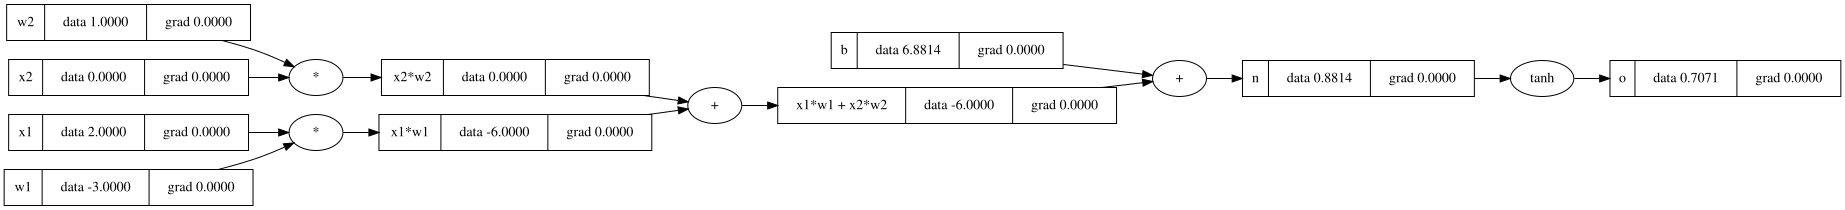

In [17]:
draw_dot(o)

In [18]:
o.backward()